<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/09-Semana/Practica22_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autor: Juan Francisco Gámez Cortés.
Matricula: 261554

Última Modificación: 18 de octubre de 2025

# Práctica #22: Ejercicios Normalización
# Objetivo:
Comprender y aplicar técnicas de normalización y transformación de datos en Machine Learning para mejorar el rendimiento de los modelos y garantizar que las características tengan una escala y distribución adecuadas del conjunto Wine

#Ejercicio 1: Normalización Min-Max

##  1.	Cargar el dataset wine de sklearn.



In [218]:
# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# data stats
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# Importar y cargar el dataset
from sklearn.datasets import load_wine

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

## 2.	Seleccionar una de las características numéricas (por ejemplo, malic_acid).
## 3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

In [219]:
#print(df.head())
#print(df.shape)
#print(df.info())

# Prueba de Shapiro-Wilk
shapiro_test = stats.shapiro(df['alcohol'])
pv = 0.05

print(f"Shapiro-Wilk Test: p-valor = {shapiro_test.pvalue:.5f}")

if shapiro_test.pvalue >= pv:
            print(f"La muestra Alcohol pasa la prueba de normalidad, valor p: {shapiro_test.pvalue:.5f} >= {pv}")
else:
            print(f"La muestra Alcohol NO pasa la prueba de normalidad, valor p: {shapiro_test.pvalue:.5f} < {pv}")


Shapiro-Wilk Test: p-valor = 0.02005
La muestra Alcohol NO pasa la prueba de normalidad, valor p: 0.02005 < 0.05


## 4.	Aplicar la normalización Min-Max a los datos seleccionados.
## 5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.


In [220]:
# Normalización Min-Max de alcohol
df_norm = df.copy()

scaler = MinMaxScaler()

df_norm['alcohol'] = scaler.fit_transform(df[['alcohol']])

print("Datos originales de alcohol:\n",df['alcohol'])
print("Datos normalizados de alcohol:\n",df_norm['alcohol'])

# Prueba de Shapiro-Wilk
shapiro_test2 = stats.shapiro(df_norm['alcohol'])
pv = 0.05

print(f"\nShapiro-Wilk Test: p-valor = {shapiro_test2.pvalue:.5f}")

if shapiro_test2.pvalue >= pv:
            print(f"La muestra Alcohol pasa la prueba de normalidad, valor p: {shapiro_test2.pvalue:.5f} >= {pv}")
else:
            print(f"La muestra Alcohol NO pasa la prueba de normalidad, valor p: {shapiro_test2.pvalue:.5f} < {pv}")



Datos originales de alcohol:
 0      14.23
1      13.20
2      13.16
3      14.37
4      13.24
       ...  
173    13.71
174    13.40
175    13.27
176    13.17
177    14.13
Name: alcohol, Length: 178, dtype: float64
Datos normalizados de alcohol:
 0      0.842105
1      0.571053
2      0.560526
3      0.878947
4      0.581579
         ...   
173    0.705263
174    0.623684
175    0.589474
176    0.563158
177    0.815789
Name: alcohol, Length: 178, dtype: float64

Shapiro-Wilk Test: p-valor = 0.02005
La muestra Alcohol NO pasa la prueba de normalidad, valor p: 0.02005 < 0.05


##  6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.


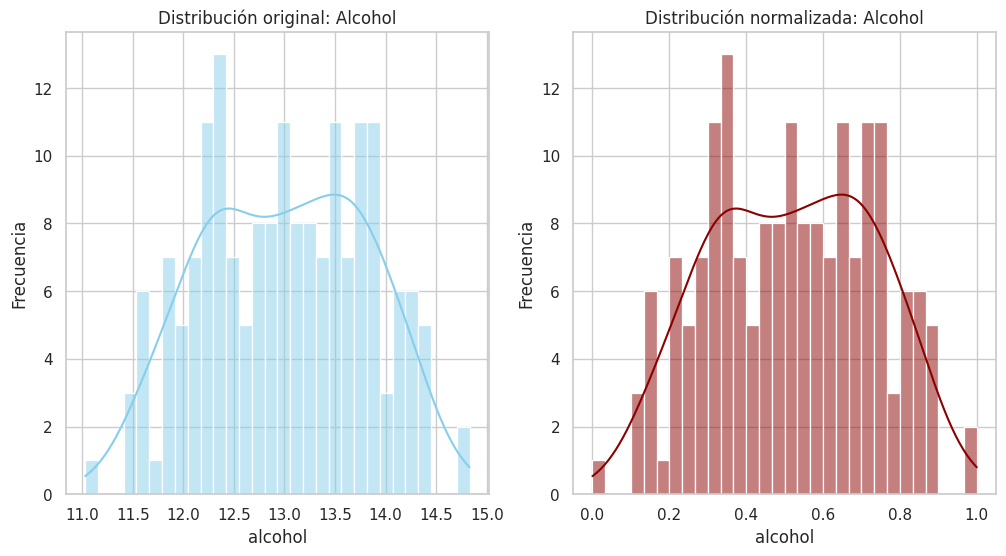

In [221]:
# Histograma Distribución original
plt.subplot(1, 2, 1)
sns.histplot(df['alcohol'], bins=30, kde=True, color="skyblue")
plt.title(f"Distribución original: Alcohol")
plt.ylabel("Frecuencia")

# Histograma Distribución normalizada
plt.subplot(1, 2, 2)
sns.histplot(df_norm['alcohol'], bins=30, kde=True, color="darkred")
plt.title(f"Distribución normalizada: Alcohol")
plt.ylabel("Frecuencia")

plt.show()

##7.	Responder las preguntas siguientes.

Preguntas:
`1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?`

La distribución de los datos NO cambio, derivado de que la normalización Min-Max también conocida como escalamiento lineal, solamente reescala los valores en un rango de 0 a 1 restando el valor mínimo y dividiendo por el máximo menos el mínimo.

En las graficas podemos observar que la distribución se mantiene y solo los rangos de valores de alcohol se modifican pasando de 11.0-15.0 a valores entre 0.0-1.0



`2. ¿Qué interpretas del p-valor antes y después de la normalización?`

Podemos observar que el p-valor es el mismo antes y después de realizar la estandarización Min-Max, por lo cual el resultado de Shapiro-Wilk Test es el mismo en el ambos casos.

# Ejercicio 2: Normalización Z-Score

##  1.	Cargar el dataset wine de sklearn.



In [222]:
# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# data stats
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Importar y cargar el dataset
from sklearn.datasets import load_wine

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

## 2.	Seleccionar una de las características numéricas (por ejemplo, malic_acid).
## 3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

In [223]:
#print(df.head())
#print(df.shape)
#print(df.info())

# Prueba de Shapiro-Wilk
shapiro_test = stats.shapiro(df['malic_acid'])
pv = 0.05

print(f"Shapiro-Wilk Test: p-valor = {shapiro_test.pvalue:.5f}")

if shapiro_test.pvalue >= pv:
            print(f"La muestra Alcohol pasa la prueba de normalidad, valor p: {shapiro_test.pvalue:.5f} >= {pv}")
else:
            print(f"La muestra Alcohol NO pasa la prueba de normalidad, valor p: {shapiro_test.pvalue:.5f} < {pv}")


Shapiro-Wilk Test: p-valor = 0.00000
La muestra Alcohol NO pasa la prueba de normalidad, valor p: 0.00000 < 0.05


## 4.	Aplicar la normalización Z-Score a los datos seleccionados.
## 5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.


In [224]:
# Normalización Z-Score de malic_acid
df_norm = df.copy()

scaler = StandardScaler()

df_norm['malic_acid'] = scaler.fit_transform(df[['malic_acid']])

print("Datos originales de malic_acid:\n",df['malic_acid'])
print("Datos normalizados de malic_acid:\n",df_norm['malic_acid'])

# Prueba de Shapiro-Wilk
shapiro_test2 = stats.shapiro(df_norm['malic_acid'])
pv = 0.05

print(f"\nShapiro-Wilk Test: p-valor = {shapiro_test2.pvalue:.5f}")

if shapiro_test2.pvalue >= pv:
            print(f"La muestra malic_acid pasa la prueba de normalidad, valor p: {shapiro_test2.pvalue:.5f} >= {pv}")
else:
            print(f"La muestra malic_acid NO pasa la prueba de normalidad, valor p: {shapiro_test2.pvalue:.5f} < {pv}")



Datos originales de malic_acid:
 0      1.71
1      1.78
2      2.36
3      1.95
4      2.59
       ... 
173    5.65
174    3.91
175    4.28
176    2.59
177    4.10
Name: malic_acid, Length: 178, dtype: float64
Datos normalizados de malic_acid:
 0     -0.562250
1     -0.499413
2      0.021231
3     -0.346811
4      0.227694
         ...   
173    2.974543
174    1.412609
175    1.744744
176    0.227694
177    1.583165
Name: malic_acid, Length: 178, dtype: float64

Shapiro-Wilk Test: p-valor = 0.00000
La muestra malic_acid NO pasa la prueba de normalidad, valor p: 0.00000 < 0.05


##  6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.


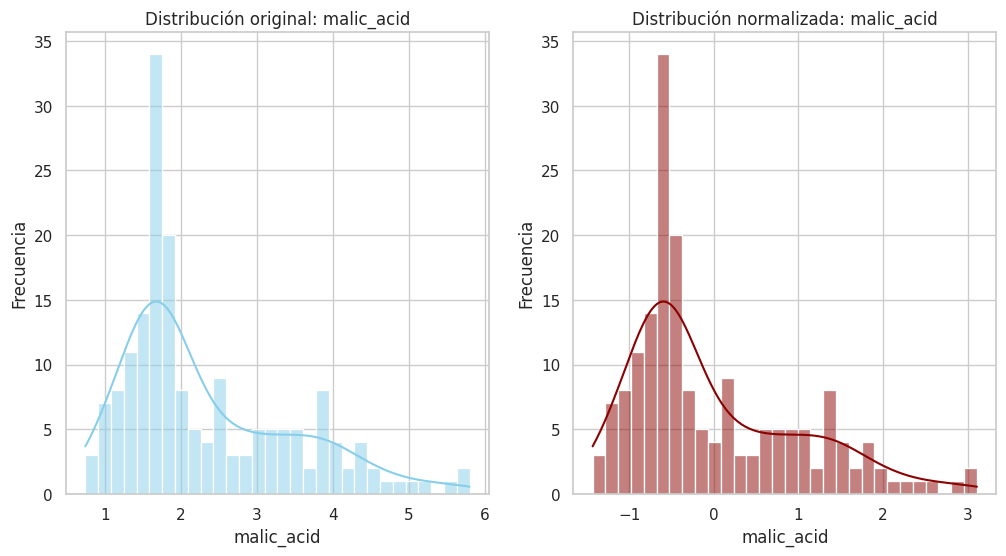

In [225]:
# Histograma Distribución original
plt.subplot(1, 2, 1)
sns.histplot(df['malic_acid'], bins=30, kde=True, color="skyblue")
plt.title(f"Distribución original: malic_acid")
plt.ylabel("Frecuencia")

# Histograma Distribución normalizada
plt.subplot(1, 2, 2)
sns.histplot(df_norm['malic_acid'], bins=30, kde=True, color="darkred")
plt.title(f"Distribución normalizada: malic_acid")
plt.ylabel("Frecuencia")

plt.show()

## 7.	Responder las preguntas siguientes.

Preguntas:


`1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?`

La distribución de los datos NO cambio, derivado de que La estandarización escala los varlores de la variable restando la media y dividiendo por la desviación estándar para desplazar la distribución a una media de cero y una desviación estándar de uno.

Podemos observar que las graficas mantienen la distribución y solo cambian los rangos de 0.5-5.8 a unidades de desviación estándar  -1.5-3.2 aproximadamente.



`2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?`

 La estandarización Z-Score puede ser útil e incluso necesaria en algunos algoritmos de aprendizaje automático cuando los datos tienen valores de entrada con diferentes escalas.

 Se usa cuando los datos estan muy dispersos.

# Ejercicio 3: Transformación Logarítmica

##  1.	Cargar un conjunto de datos aleatorios generados con numpy.

In [226]:
# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Generar el dataset aleatorio: simularemos las ventas de libros

np.random.seed(2)

#Generamos un arreglo de 2000 datos aleatorios, creando una cola a la derecha
datos = np.random.lognormal(mean=5.0, sigma=2.0, size=2000)

print(datos)

[ 64.48833181 132.61714202   2.07012255 ... 843.05014856 116.31412113
 673.46978348]


## 2.	Aplicar una transformación logarítmica (np.log) a los datos.





In [227]:
# Transformación logaritmica de datos
datos_transformados = np.log(datos)

# Estadísticas descriptivas
def summary_stats(x):
    return {
        'n': len(x),
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=1),
        'skew': stats.skew(x),
        'kurtosis': stats.kurtosis(x)
    }

resumen = summary_stats(datos)
resumen_trans = summary_stats(datos_transformados)


In [228]:
df_compare = pd.DataFrame({
    'Original': resumen,
    'Transformado': resumen_trans
})
print(df_compare)



              Original  Transformado
n          2000.000000   2000.000000
mean       1311.501892      4.941445
median      136.338825      4.915143
std       13318.774246      1.979653
skew         35.812409      0.067958
kurtosis   1442.986578      0.177309


## 3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

In [229]:
# Prueba de Shapiro-Wilk datos originales
shapiro_test_orig = stats.shapiro(datos)
pv = 0.05

print(f"Shapiro-Wilk Test Original: p-valor = {shapiro_test_orig.pvalue:.5f}")

if shapiro_test_orig.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasa la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} < {pv}")


# Prueba de Shapiro-Wilk a datos transformados
shapiro_test_trans = stats.shapiro(datos_transformados)

print(f"\nShapiro-Wilk Test Transformado: p-valor = {shapiro_test_trans.pvalue:.5f}")

if shapiro_test_trans.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} < {pv}")


Shapiro-Wilk Test Original: p-valor = 0.00000
Los datos NO pasa la prueba de normalidad, valor p: 0.00000 < 0.05

Shapiro-Wilk Test Transformado: p-valor = 0.20349
Los datos pasan la prueba de normalidad, valor p: 0.20349 >= 0.05


## 4.	Graficar los datos originales y transformados utilizando matplotlib.




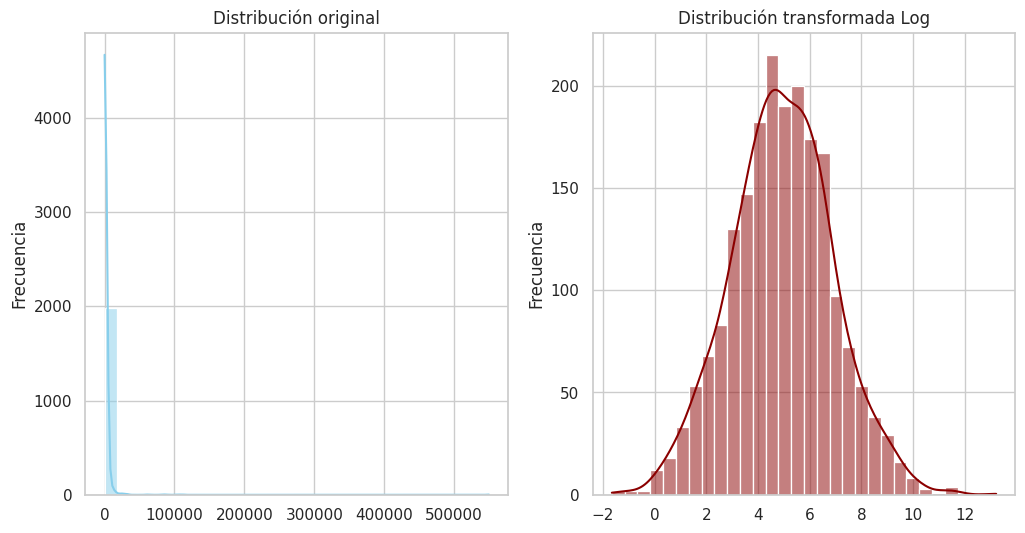

In [230]:

# Histograma Distribución original
plt.subplot(1, 2, 1)
sns.histplot(datos, bins=30, kde=True, color="skyblue")
plt.title(f"Distribución original")
plt.ylabel("Frecuencia")

# Histograma Distribución transformada
plt.subplot(1, 2, 2)
sns.histplot(datos_transformados, bins=30, kde=True, color="darkred")
plt.title(f"Distribución transformada Log")
plt.ylabel("Frecuencia")

plt.show()


## 5.	Responder las preguntas siguientes.

Preguntas:


`1.	¿Cómo afectó la transformación logarítmica a la distribución de los datos?`

Para nuestro caso simulado de ventas de libros, la transformación logaritmica nos fue de ayuda para corregir la cola larga hacia la derecha y transformar la distribución a una forma normal.



`2.	¿Qué interpretas del p-valor antes y después de la transformación logarítmica?`

Después de realizar la transformación logaritmica resulto una distribución normal, el p-valor original esta fuera del parametro que nos indica una distribución normal, sin embargo, posterior a la transformación el p-valor cumple con el rango de distribución normal

# Ejercicio 4: Transformación Raíz Cuadrada

##  1.	Cargar un conjunto de datos aleatorios generados con numpy.

In [231]:
# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Generar el dataset aleatorio: simularemos artículos comprados por 1000 clientes

np.random.seed(42)

#Generamos un arreglo de 1000 datos aleatorios, creando una cola a la derecha
datos = np.random.poisson(lam=3, size=1000)

print(datos)

[4 1 3 3 2 3 2 3 0 2 4 2 1 3 4 4 1 2 3 2 3 4 1 3 3 3 5 0 1 4 3 1 7 3 4 2 1
 4 4 1 2 3 5 5 3 2 3 3 1 6 1 5 4 3 2 3 2 6 2 6 3 0 5 0 6 2 4 3 5 8 4 1 3 0
 0 2 4 1 5 3 0 4 1 6 3 1 1 0 3 2 4 5 1 0 5 5 1 0 2 2 2 6 6 5 5 0 2 5 5 1 4
 3 2 2 2 6 4 1 1 1 5 3 1 3 6 2 5 2 1 7 8 0 3 6 1 9 3 3 6 2 0 4 0 3 5 5 4 1
 1 1 2 3 1 1 1 2 3 2 2 3 2 4 4 1 2 1 2 3 2 4 3 4 1 1 1 2 2 5 5 2 2 3 2 1 2
 5 5 3 4 1 3 4 3 3 3 3 5 3 5 2 2 5 3 3 3 6 6 3 5 2 4 3 2 4 1 3 1 3 3 1 2 4
 2 5 0 3 2 0 2 2 4 2 1 1 0 2 4 3 5 5 3 4 1 3 4 4 3 2 2 3 3 4 0 2 4 2 4 3 2
 3 7 3 5 8 1 2 2 1 3 4 1 7 6 2 2 1 0 4 3 4 5 1 1 2 6 3 3 2 6 1 3 1 2 4 5 8
 2 2 4 0 4 3 6 2 2 3 6 0 4 4 3 4 4 4 1 5 6 0 4 2 2 3 1 1 5 0 2 3 2 2 1 1 3
 1 2 0 1 7 6 1 1 4 5 5 0 5 3 7 3 3 3 4 4 3 3 3 2 4 1 0 7 1 1 1 3 1 3 6 1 2
 3 3 7 5 2 1 7 5 3 2 3 2 4 3 3 6 1 4 2 2 3 3 1 3 2 4 6 5 5 3 3 0 3 4 6 2 1
 2 2 1 2 5 6 4 2 5 4 3 4 0 2 2 3 5 3 5 2 4 5 2 1 0 4 3 4 1 1 2 2 1 2 5 2 3
 4 2 2 2 5 3 2 4 7 1 7 3 1 2 1 4 3 2 1 2 3 3 1 7 2 3 4 3 6 5 2 1 5 3 5 1 3
 3 3 2 1 4 1 7 2 3 3 6 2 

## 2.	Aplicar una transformación de raíz cuadrada a los datos.





In [232]:
# Transformación de raíz cuadrada de datos
datos_transformados = np.sqrt(datos)

# Estadísticas descriptivas
def summary_stats(x):
    return {
        'n': len(x),
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=1),
        'skew': stats.skew(x),
        'kurtosis': stats.kurtosis(x)
    }

resumen = summary_stats(datos)
resumen_trans = summary_stats(datos_transformados)

df_compare = pd.DataFrame({
    'Original': resumen,
    'Transformado': resumen_trans
})
print(df_compare)


             Original  Transformado
n         1000.000000   1000.000000
mean         2.959000      1.617206
median       3.000000      1.732051
std          1.733876      0.586507
skew         0.531142     -0.716602
kurtosis    -0.031009      0.897123


## 3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

In [233]:
# Prueba de Shapiro-Wilk datos originales
shapiro_test_orig = stats.shapiro(datos)
pv = 0.05

print(f"Shapiro-Wilk Test Original: p-valor = {shapiro_test_orig.pvalue:.5f}")

if shapiro_test_orig.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasa la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} < {pv}")


# Prueba de Shapiro-Wilk a datos transformados
shapiro_test_trans = stats.shapiro(datos_transformados)

print(f"\nShapiro-Wilk Test Transformado: p-valor = {shapiro_test_trans.pvalue:.5f}")

if shapiro_test_trans.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} < {pv}")


Shapiro-Wilk Test Original: p-valor = 0.00000
Los datos NO pasa la prueba de normalidad, valor p: 0.00000 < 0.05

Shapiro-Wilk Test Transformado: p-valor = 0.00000
Los datos NO pasan la prueba de normalidad, valor p: 0.00000 < 0.05


## 4.	Graficar los datos originales y transformados utilizando matplotlib.




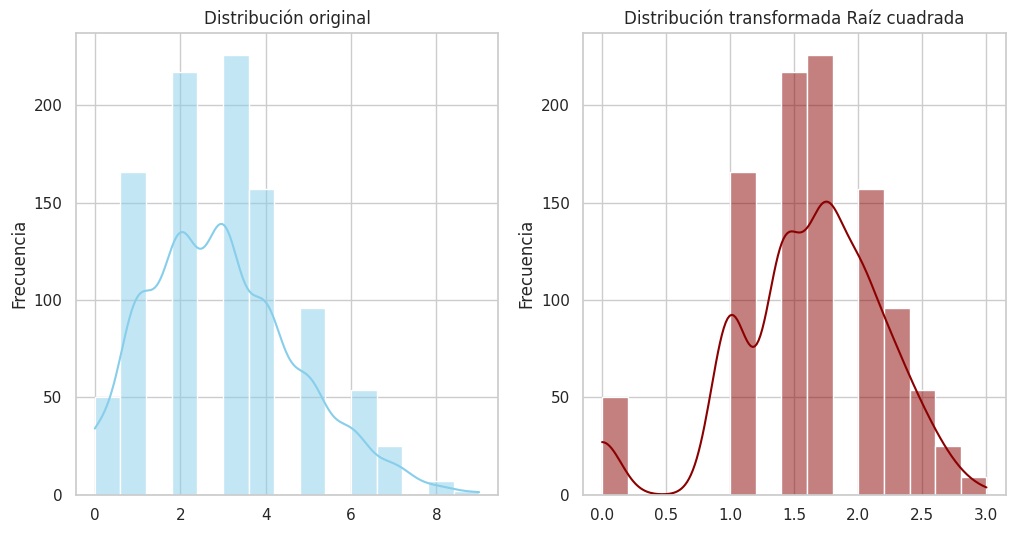

In [234]:

# Histograma Distribución original
plt.subplot(1, 2, 1)
sns.histplot(datos, bins=15, kde=True, color="skyblue")
plt.title(f"Distribución original")
plt.ylabel("Frecuencia")

# Histograma Distribución transformada
plt.subplot(1, 2, 2)
sns.histplot(datos_transformados, bins=15, kde=True, color="darkred")
plt.title(f"Distribución transformada Raíz cuadrada")
plt.ylabel("Frecuencia")

plt.show()


## 5.	Responder las preguntas siguientes.

Preguntas:


`1.	¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?`

Para nuestro caso simulado de articulos comprados por un cliente, tenemos inicialmente una distribución con una ligera cola a la derecha, posterior a a aplicar la transformación de raíz cuadrada, la distribución cambia un poco reduciendo la cola de la derecha y ajustandose a la normal, sin embargo, no lo suficiente para considerarla una campana de gauss.



`2.	¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?`

El efecto de aplicar transformación de raíz cuadrada es la reduccion de los valores extremos, ajustando al centro los valores y reduciendo la asimetria positiva.

# Ejercicio 5: Transformación Box-Cox

##  1.	Cargar un conjunto de datos aleatorios generados con numpy.

In [235]:
# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Generar el dataset aleatorio

np.random.seed(42)

#Generamos un arreglo de 1000 datos aleatorios, creando una cola a la derecha
datos = np.random.chisquare(df=2, size=1000)

print(datos)

[9.38536180e-01 6.02024286e+00 2.63349139e+00 1.82588511e+00
 3.39249741e-01 3.39192584e-01 1.19677537e-01 4.02246173e+00
 1.83816431e+00 2.46250012e+00 4.15986160e-02 7.00711495e+00
 3.57285909e+00 4.77375250e-01 4.01357977e-01 4.05222846e-01
 7.25507459e-01 1.48785566e+00 1.13107413e+00 6.88445985e-01
 1.89274175e+00 3.00469057e-01 6.91031024e-01 9.12554436e-01
 1.21786938e+00 3.07587202e+00 4.45471724e-01 1.44405831e+00
 1.79500944e+00 9.51276995e-02 1.87066604e+00 3.73922504e-01
 1.34527862e-01 5.94737559e+00 6.74126068e+00 3.30466315e+00
 7.26575720e-01 2.05554630e-01 2.30550153e+00 1.16018169e+00
 2.60304468e-01 1.36709446e+00 6.99874429e-02 4.80084577e+00
 5.98915554e-01 2.17251160e+00 7.47093163e-01 1.46822179e+00
 1.58244760e+00 4.08777199e-01 6.98561427e+00 2.98449075e+00
 5.61018884e+00 4.50430400e+00 1.82210882e+00 5.09887076e+00
 1.85310918e-01 4.36269389e-01 9.25639314e-02 7.87064174e-01
 9.84260584e-01 6.33120886e-01 3.52911573e+00 8.82453999e-01
 6.59605680e-01 1.564814

## 2.	Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.





In [236]:
# Transformación de Box-Cox de datos
datos_transformados, lambda_optimo = stats.boxcox(datos)

# Estadísticas descriptivas
def summary_stats(x):
    return {
        'n': len(x),
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=1),
        'skew': stats.skew(x),
        'kurtosis': stats.kurtosis(x)
    }

resumen = summary_stats(datos)
resumen_trans = summary_stats(datos_transformados)

df_compare = pd.DataFrame({
    'Original': resumen,
    'Transformado': resumen_trans
})
print(df_compare)
print("El valor de lambda optimo es:",lambda_optimo)


             Original  Transformado
n         1000.000000   1000.000000
mean         1.945012      0.268812
median       1.373565      0.330140
std          1.945020      1.212371
skew         1.865034     -0.055252
kurtosis     5.217828     -0.471640
El valor de lambda optimo es: 0.24618453123707149


## 3.	Realizar una prueba de normalidad sobre los datos originales y transformados.

In [237]:
# Prueba de Shapiro-Wilk datos originales
shapiro_test_orig = stats.shapiro(datos)
pv = 0.05

print(f"Shapiro-Wilk Test Original: p-valor = {shapiro_test_orig.pvalue:.5f}")

if shapiro_test_orig.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasa la prueba de normalidad, valor p: {shapiro_test_orig.pvalue:.5f} < {pv}")


# Prueba de Shapiro-Wilk a datos transformados
shapiro_test_trans = stats.shapiro(datos_transformados)

print(f"\nShapiro-Wilk Test Transformado: p-valor = {shapiro_test_trans.pvalue:.5f}")

if shapiro_test_trans.pvalue >= pv:
            print(f"Los datos pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} >= {pv}")
else:
            print(f"Los datos NO pasan la prueba de normalidad, valor p: {shapiro_test_trans.pvalue:.5f} < {pv}")


Shapiro-Wilk Test Original: p-valor = 0.00000
Los datos NO pasa la prueba de normalidad, valor p: 0.00000 < 0.05

Shapiro-Wilk Test Transformado: p-valor = 0.00368
Los datos NO pasan la prueba de normalidad, valor p: 0.00368 < 0.05


## 4.	Graficar los datos originales y transformados utilizando matplotlib.




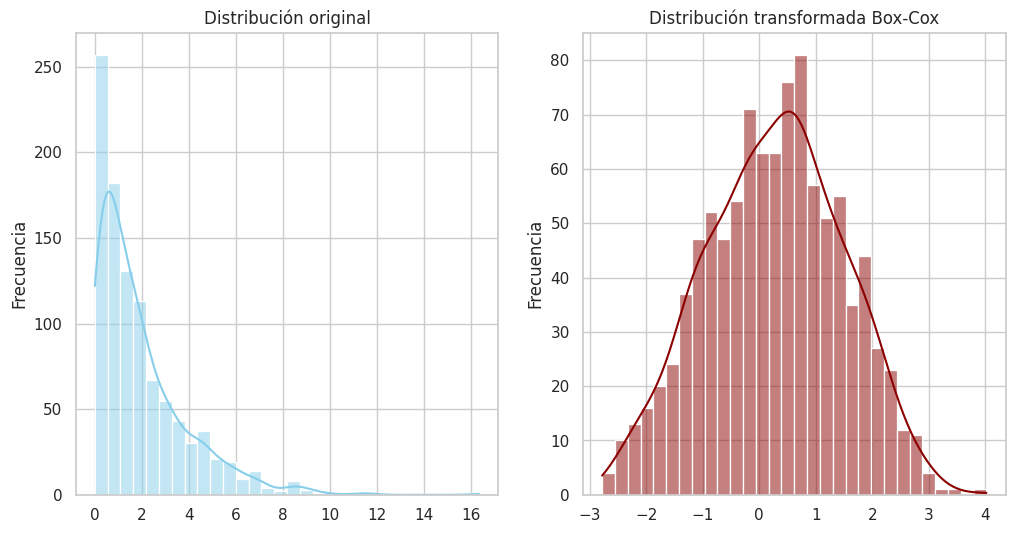

In [238]:

# Histograma Distribución original
plt.subplot(1, 2, 1)
sns.histplot(datos, bins=30, kde=True, color="skyblue")
plt.title(f"Distribución original")
plt.ylabel("Frecuencia")

# Histograma Distribución transformada
plt.subplot(1, 2, 2)
sns.histplot(datos_transformados, bins=30, kde=True, color="darkred")
plt.title(f"Distribución transformada Box-Cox")
plt.ylabel("Frecuencia")

plt.show()


## 5.	Responder las preguntas siguientes.

Preguntas:


`1.	¿Cómo afectó la transformación Box-Cox a la distribución de los datos?`

Para nuestro caso simulado inicial con distribución chi cuadrada tenemos un sesgo a la derecha, luego de aplicar la transformación Box-Cox se corrigió la asimetría y convirtió la distribución en una muy similar a la normal.



`2.	¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?`

Al aplicar la transformación de Box-Cox se encuentra un lambda optimo que hace que la distribución sea lo más parecido a la normal.

Si λ≈0.5, es mejor aplicar una transformación Raíz Cuadrada.

Si λ≈0.0, es mejor aplicar una transformación un Logaritmica.

En nuestro caso λ≈0.24 lo que indica que es mejor una transformación intermedia.